# Predicao de Falhas em SSDs - Regressao Logistica (Baseline)

Este notebook treina um **baseline de Regressao Logistica** para o mesmo
problema resolvido em `AMA_projeto_LSTM.ipynb`: prever, para cada disco e
cada dia, se ele **vai falhar dentro dos proximos `CONTAMINATION_LEVEL` dias**.

Para que a comparacao entre os tres modelos do trabalho (LSTM, Regressao
Logistica, Random Forest) seja justa, este notebook reaproveita - via o
modulo `ssd_utils.py` - exatamente:

- **os mesmos indices de split** treino/teste/validacao do notebook do LSTM
  (`[0:3740]`, `[3740:4541]`, `[4541:]`);
- **a mesma funcao de rotulagem** `create_class_labels` (copia literal da
  celula 8 daquele notebook), com `contamination_level = 7`;
- **as mesmas metricas de avaliacao**: acuracia, precisao, recall, F1-score
  e matriz de confusao, calculadas apenas sobre os timesteps validos
  (`mask == 1`), igual ao `batch_evaluation` do LSTM.

### Por que features de janela deslizante?

O LSTM enxerga a sequencia inteira do disco ate o timestep atual. Modelos
tabulares como Regressao Logistica e Random Forest recebem um vetor fixo por
amostra - nao uma sequencia. Para nao competir em desvantagem (apenas o valor
do dia atual, sem nenhum contexto temporal), cada amostra `(disco, dia)`
recebe um resumo dos ultimos `WINDOW` dias de leitura SMART:

```
[valor atual, media, desvio padrao, minimo, maximo]   (por atributo, 24 x 5 = 120 features)
```

Isso da aos modelos tabulares uma nocao de tendencia recente (ex.: um atributo
SMART subindo de forma constante nas ultimas 2 semanas), sem dar acesso ao
historico completo como o LSTM tem.

### Resultados

Ao final, o notebook salva em disco (`resultados_logistic_regression.pkl`)
um dicionario com metricas, predicoes, probabilidades e metadados - para que
os graficos comparativos finais (ROC, precisao-recall, barras de metricas
entre os 3 modelos) possam ser gerados depois, junto com os resultados do
Random Forest e do LSTM.


In [1]:
# ===== Configuracao =====
import os
import time
import pickle

import numpy as np

import os
import sys

# --- Resolucao robusta de caminhos (independente do diretorio de trabalho) ---
def _encontra_raiz(inicio=None):
    """Sobe na arvore ate achar comum/ssd_utils.py."""
    d = os.path.abspath(inicio or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, 'comum', 'ssd_utils.py')):
            return d
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError('raiz do projeto (com comum/ssd_utils.py) nao encontrada')
        d = pai

PROJ_ROOT = _encontra_raiz()
COMUM_DIR = os.path.join(PROJ_ROOT, 'comum')
H7_DIR = os.path.join(PROJ_ROOT, 'horizonte_7dias')
H30_DIR = os.path.join(PROJ_ROOT, 'horizonte_30dias')
EXP_DIR = os.path.join(PROJ_ROOT, 'experimentos')
if COMUM_DIR not in sys.path:
    sys.path.insert(0, COMUM_DIR)
# ---------------------------------------------------------------------------
import ssd_utils as ssd

DATA_DIR = COMUM_DIR        # data.pickle / mask.pickle (pasta comum/)
OUTPUT_DIR = H7_DIR         # resultados, modelos e figuras deste notebook
WINDOW = 90                 # dias de historico resumidos em cada amostra (atual/media/desvio/min/max); ver AMA_experimento_janela.ipynb
CONTAMINATION_LEVEL = 7     # horizonte de previsao de falha - igual ao notebook do LSTM
RANDOM_STATE = 42

## 1. Carregamento dos dados, rotulos e construcao das features

`create_class_labels` e a mesma funcao usada no LSTM: rotula como `1` os
ultimos `CONTAMINATION_LEVEL` dias validos antes da falha (todos os dias
validos, se o disco viveu menos que isso).

`build_windowed_features` constroi, para cada `(disco, dia)`, o vetor de 120
features descrito acima (vetorizado com `pandas.groupby(...).rolling(...)`,
sem vazar dados de um disco para o outro nem incluir padding na janela - a
mascara e monotonica: prefixo de 1s seguido de sufixo de 0s).

In [2]:
data, mask = ssd.load_dataset(DATA_DIR)
print(f'data: {data.shape}   mask: {mask.shape}')

labels = ssd.create_class_labels(data, mask, CONTAMINATION_LEVEL)
print(f'labels: {labels.shape}   positivos: {int(labels.sum())} '
      f'({labels.mean()*100:.3f}% dos timesteps - desbalanceamento extremo, '
      f'class_weight="balanced" e essencial)')

start = time.time()
X_all, disco_id, timestep, feature_cols = ssd.build_windowed_features(data, mask, window=WINDOW)
print(f'X_all: {X_all.shape}   ({len(feature_cols)} features por amostra)')
print(f'Tempo de construcao das features: {time.time() - start:.1f}s')

data: (5343, 360, 24)   mask: (5343, 360)
labels: (5343, 360)   positivos: 37320 (1.940% dos timesteps - desbalanceamento extremo, class_weight="balanced" e essencial)


X_all: (1923480, 120)   (120 features por amostra)
Tempo de construcao das features: 20.8s


## 2. Divisao treino / teste / validacao

Mesmos indices de disco do notebook do LSTM. Em seguida descartamos o padding
(`mask == 0`) - assim como o `batch_evaluation` do LSTM ignora essas posicoes
ao calcular metricas e perda.

In [3]:
splits_idx = ssd.split_indices(n_discos=data.shape[0])
y_flat = labels.reshape(-1)
mask_flat = mask.reshape(-1)

train = ssd.select_split(X_all, disco_id, timestep, y_flat, mask_flat, splits_idx['train'])
test = ssd.select_split(X_all, disco_id, timestep, y_flat, mask_flat, splits_idx['test'])
validation = ssd.select_split(X_all, disco_id, timestep, y_flat, mask_flat, splits_idx['validation'])

for nome, split in [('treino', train), ('teste', test), ('validacao', validation)]:
    n = len(split['y'])
    n_pos = int(split['y'].sum())
    print(f'{nome:10s}: {n:>9,} amostras validas | positivas: {n_pos:>6,} ({n_pos/n*100:.3f}%)')

treino    : 1,240,487 amostras validas | positivas: 26,126 (2.106%)
teste     :   265,245 amostras validas | positivas:  5,593 (2.109%)
validacao :   267,254 amostras validas | positivas:  5,601 (2.096%)


## 3. Padronizacao das features

A Regressao Logistica e sensivel a escala das variaveis. O `StandardScaler` e
ajustado **apenas no conjunto de treino** (para nao vazar estatisticas de
teste/validacao) e depois aplicado aos tres conjuntos.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(train['X'])
X_test = scaler.transform(test['X'])
X_validation = scaler.transform(validation['X'])

y_train, y_test, y_validation = train['y'], test['y'], validation['y']

## 4. Busca de hiperparametros

Como apenas ~0,3-2% das amostras sao positivas (falha iminente),
`class_weight='balanced'` e usado para compensar o desbalanceamento.
A busca varia a regularizacao (`C`, `penalty`) com `RandomizedSearchCV`,
otimizando a **Average Precision da classe positiva** (acuracia seria enganosa aqui:
um modelo que sempre prevê "nao vai falhar" teria acuracia altissima e
recall zero).

A busca otimiza **Average Precision** (`scoring='average_precision'`), e
nao F1: a comparacao entre os modelos do trabalho e feita por AP (metrica
de ranking, independente de limiar) e o ponto de operacao e escolhido
depois, na validacao. Selecionar hiperparametros pelo mesmo criterio evita
o vies do corte fixo de 0,5 embutido no F1 do `scoring='f1'`.

A busca roda numa **subamostra estratificada** do treino (ate 300 mil linhas) e o **ajuste final** e feito no treino completo - resultado praticamente igual e muito mais rapido (essencial no Colab, com 2 nucleos).

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, train_test_split

param_distributions = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.0, 0.5, 1.0],     # 0 = L2, 1 = L1 (substitui o antigo 'penalty')
}

base_lr = LogisticRegression(
    penalty='elasticnet', solver='saga',
    class_weight='balanced',
    max_iter=5000, tol=1e-3,         # era max_iter=2000; evita nao-convergencia
    random_state=RANDOM_STATE,
)

search = RandomizedSearchCV(
    base_lr,
    param_distributions=param_distributions,
    n_iter=8,
    scoring='average_precision',
    cv=3,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2,
)

# Busca numa subamostra estratificada do treino; o fit final (mais abaixo) e no
# treino completo. Pratica honesta e muito mais leve - essencial no Colab (2 nucleos).
SUBSAMPLE_SIZE = min(300_000, len(X_train) - 2)
X_search, _, y_search, _ = train_test_split(
    X_train, y_train, train_size=SUBSAMPLE_SIZE,
    stratify=y_train, random_state=RANDOM_STATE,
)
print(f'Busca em subamostra: {X_search.shape[0]:,} de {len(X_train):,} amostras de treino')

start = time.time()
search.fit(X_search, y_search)
search_time = time.time() - start

print(f'Melhores hiperparametros: {search.best_params_}')
print(f'AP medio (CV) do melhor modelo: {search.best_score_:.4f}')
print(f'Tempo da busca: {search_time/60:.1f} min')

Busca em subamostra: 300,000 de 1,240,487 amostras de treino
Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\len108\Documents\pv\ErroSSD\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Melhores hiperparametros: {'l1_ratio': 0.5, 'C': 0.01}
AP medio (CV) do melhor modelo: 0.0796
Tempo da busca: 2.7 min


## 5. Treino do modelo final

Re-treina o melhor estimador encontrado na busca sobre todo o conjunto de
treino, medindo o tempo de treino isoladamente (util para comparar custo
computacional entre os tres modelos no artigo).

In [6]:
best_lr = LogisticRegression(
    **search.best_params_,
    penalty='elasticnet', solver='saga',
    class_weight='balanced',
    max_iter=5000, tol=1e-3,
    random_state=RANDOM_STATE,
)

start = time.time()
best_lr.fit(X_train, y_train)
train_time = time.time() - start
print(f'Tempo de treino do modelo final: {train_time:.1f}s')

C:\Users\len108\Documents\pv\ErroSSD\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Tempo de treino do modelo final: 75.6s


## 6. Avaliacao

Mesmas metricas do notebook do LSTM - acuracia, precisao, recall, F1-score e
matriz de confusao - calculadas em teste e validacao. O **recall da classe
"vai falhar"** e a metrica mais critica: deixar de prever uma falha custa
muito mais caro do que um alarme falso ocasional.

In [7]:
test_proba = best_lr.predict_proba(X_test)[:, 1]
val_proba  = best_lr.predict_proba(X_validation)[:, 1]

thr = ssd.best_threshold_f1(y_validation, val_proba)   # escolhido na validacao
print(f'Limiar otimo (F1): {thr:.4f}')

test_pred = (test_proba >= thr).astype(int)
val_pred  = (val_proba  >= thr).astype(int)

test_metrics = ssd.evaluate_predictions(y_test, test_pred)
val_metrics  = ssd.evaluate_predictions(y_validation, val_pred)
ssd.print_metrics('teste', test_metrics); print()
ssd.print_metrics('validacao', val_metrics)

Limiar otimo (F1): 0.8301


--- TESTE ---
Accuracy:  0.9712
Precision: 0.1812
Recall:    0.1033
F1-score:  0.1316
Matriz de confusão ([[TN, FP], [FN, TP]]):
[[257041   2611]
 [  5015    578]]

--- VALIDACAO ---
Accuracy:  0.9710
Precision: 0.1752
Recall:    0.1032
F1-score:  0.1299
Matriz de confusão ([[TN, FP], [FN, TP]]):
[[258931   2722]
 [  5023    578]]


## 7. Salvando resultados para comparacao posterior

Salvamos dois arquivos:

- `modelo_logistic_regression.pkl` - o modelo treinado + o `scaler` (para
  reutilizar/inspecionar depois sem re-treinar);
- `resultados_logistic_regression.pkl` - metricas, predicoes, probabilidades,
  hiperparametros e tempos, no **mesmo formato** que o notebook de Random
  Forest usara. Isso permite montar facilmente os graficos comparativos
  (curvas ROC, precisao-recall, barras de metricas) entre os tres modelos
  para a apresentacao, sem precisar re-rodar nada.

In [8]:
results = {
    'model_name': 'Logistic Regression',
    'contamination_level': CONTAMINATION_LEVEL,
    'window': WINDOW,
    'feature_cols': feature_cols,
    'best_params': search.best_params_,
    'cv_best_ap': search.best_score_,
    'search_time_seconds': search_time,
    'train_time_seconds': train_time,
    'threshold': thr,
    'metrics': {'test': test_metrics, 'validation': val_metrics},
    'predictions': {
        'test': {
            'disco_id': test['disco_id'], 'timestep': test['timestep'],
            'y_true': y_test, 'y_pred': test_pred, 'y_proba': test_proba,
        },
        'validation': {
            'disco_id': validation['disco_id'], 'timestep': validation['timestep'],
            'y_true': y_validation, 'y_pred': val_pred, 'y_proba': val_proba,
        },
    },
}

ssd.save_results(os.path.join(OUTPUT_DIR, 'resultados_logistic_regression.pkl'), **results)

with open(os.path.join(OUTPUT_DIR, 'modelo_logistic_regression.pkl'), 'wb') as f:
    pickle.dump({'model': best_lr, 'scaler': scaler}, f)
print('Modelo + scaler salvos em modelo_logistic_regression.pkl')

Resultados salvos em: C:\Users\len108\Documents\pv\ErroSSD\horizonte_7dias\resultados_logistic_regression.pkl
Modelo + scaler salvos em modelo_logistic_regression.pkl


## Curva de aprendizagem

Desempenho (**Average Precision**) em funcao do tamanho do conjunto de treino.
Para cada fracao (de 2% ate **100%** do treino) o modelo e re-treinado e avaliado
no **mesmo split de validacao do projeto** (o split por disco usado no numero
final) - entao o **ultimo ponto coincide com o AP do modelo final** mostrado em
`AMA_comparacao_modelos`. A linha tracejada e o AP medido no proprio treino
(diagnostico de overfitting); a linha cheia e a validacao. E um diagnostico extra
e **nao** altera o modelo salvo nem os resultados.

> Re-treina o modelo em fracoes crescentes (incl. 100% = treino completo), entao
> custa ~2x um treino. Para acelerar, reduza a lista `fracs`. Os hiperparametros
> sao os ja escolhidos na busca (lidos da memoria ou do `.pkl` de resultados).

Curva de aprendizagem (avaliando na validacao do projeto):


C:\Users\len108\Documents\pv\ErroSSD\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  treino=   24,809  AP_treino=0.0696  AP_val=0.0693


C:\Users\len108\Documents\pv\ErroSSD\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  treino=   62,024  AP_treino=0.0789  AP_val=0.0803


...

  treino=  310,121  AP_treino=0.0795  AP_val=0.0768


C:\Users\len108\Documents\pv\ErroSSD\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  treino=  620,243  AP_treino=0.0786  AP_val=0.0812


C:\Users\len108\Documents\pv\ErroSSD\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  treino=1,240,487  AP_treino=0.0760  AP_val=0.0745


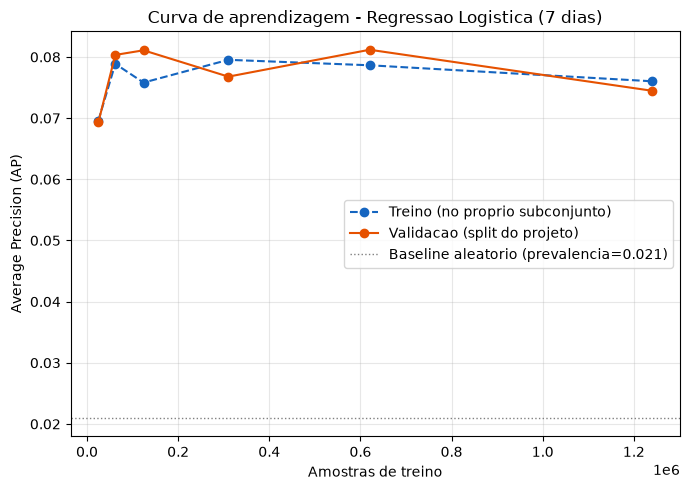

Curva de aprendizagem salva em lr_learning_curve.png  (ultimo ponto = AP do modelo final na validacao)
Dados da curva salvos em lr_learning_curve.pkl


In [9]:
# Curva de aprendizagem FIEL: AP x tamanho do treino, avaliando no split de validacao do projeto.
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# hiperparametros: usa os da busca (se na memoria) ou le do .pkl de resultados
try:
    _bp = dict(search.best_params_)
except NameError:
    with open(os.path.join(OUTPUT_DIR, 'resultados_logistic_regression.pkl'), 'rb') as _f:
        _bp = pickle.load(_f)['best_params']

base_est = make_pipeline(
    StandardScaler(),
    LogisticRegression(**_bp, penalty='elasticnet', solver='saga',
                       class_weight='balanced', max_iter=5000, tol=1e-3,
                       random_state=RANDOM_STATE))

Xtr_full, ytr_full = train['X'], train['y']     # treino completo (sem escalonar; pipeline cuida disso)
Xval, yval = validation['X'], validation['y']   # split de validacao do projeto (mesmo do numero final)

fracs = [0.02, 0.05, 0.1, 0.25, 0.5, 1.0]
sizes, ap_tr, ap_va = [], [], []
print('Curva de aprendizagem (avaliando na validacao do projeto):')
for fr in fracs:
    if fr < 1.0:
        X_s, _, y_s, _ = train_test_split(Xtr_full, ytr_full, train_size=fr,
                                          stratify=ytr_full, random_state=RANDOM_STATE)
    else:
        X_s, y_s = Xtr_full, ytr_full
    est = clone(base_est)
    est.fit(X_s, y_s)
    ap_v = average_precision_score(yval, est.predict_proba(Xval)[:, 1])
    ap_t = average_precision_score(y_s, est.predict_proba(X_s)[:, 1])
    sizes.append(len(y_s)); ap_va.append(ap_v); ap_tr.append(ap_t)
    print(f'  treino={len(y_s):>9,}  AP_treino={ap_t:.4f}  AP_val={ap_v:.4f}')

sizes = np.array(sizes); ap_tr = np.array(ap_tr); ap_va = np.array(ap_va)
_prev = float(np.mean(yval))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sizes, ap_tr, 'o--', color='#1565C0', label='Treino (no proprio subconjunto)')
ax.plot(sizes, ap_va, 'o-', color='#E65100', label='Validacao (split do projeto)')
ax.axhline(_prev, color='gray', ls=':', lw=1, label=f'Baseline aleatorio (prevalencia={_prev:.3f})')
ax.set_xlabel('Amostras de treino')
ax.set_ylabel('Average Precision (AP)')
ax.set_title('Curva de aprendizagem - Regressao Logistica (7 dias)')
ax.legend(loc='best')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'lr_learning_curve.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Curva de aprendizagem salva em lr_learning_curve.png  (ultimo ponto = AP do modelo final na validacao)')

# Salva os dados para a figura consolidada da comparacao (std=0: estimativa unica por ponto)
with open(os.path.join(OUTPUT_DIR, 'lr_learning_curve.pkl'), 'wb') as _f:
    pickle.dump({'model_name': 'Logistic Regression', 'scoring': 'average_precision',
                 'train_sizes': sizes,
                 'train_mean': ap_tr, 'train_std': np.zeros_like(ap_tr),
                 'val_mean': ap_va, 'val_std': np.zeros_like(ap_va)}, _f)
print('Dados da curva salvos em lr_learning_curve.pkl')
